<a href="https://colab.research.google.com/github/MiguelDS021/Projeto-Inadimplencia-German/blob/main/Projeto_Inadimplencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto - German Credit Data
### Classificação de risco de crédito (Good/Bad) com Regressão Logístic

## 1. Importação e Encoding dos Dados
Tradução dos códigos (A11, A30, A61...) para texto legível, usando dicionário aninhado para evitar cruzamento indevido entre colunas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/german.data", sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
col_nome = ["checking_account", "duration", "credit_history", "purpose", "credit_amount",
            "savings", "employment", "installment_rate","personal_status_sex", "other_debtors",
            "residence_since", "property", "age", "other_installment_plans", "housing",
            "existing_credits", "job", "dependents", "telephone", "foreign_worker", "class"]

df.columns = col_nome
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
display(df)

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [5]:
linhas = {
    'checking_account': {
        'A11': '... < 0 DM',
        'A12': '0 <= ... < 200 DM',
        'A13': '... >= 200 DM / salary assignments for at least 1 year',
        'A14': 'no checking account',
    },
    'credit_history': {
        'A30': 'no credits taken/ all credits paid back duly',
        'A31': 'all credits at this bank paid back duly',
        'A32': 'existing credits paid back duly till now',
        'A33': 'delay in paying off in the past',
        'A34': 'critical account/ other credits existing (not at this bank)',
    },
    'purpose': {
        'A40': 'car (new)',
        'A41': 'car (used)',
        'A42': 'furniture/equipment',
        'A43': 'radio/television',
        'A44': 'domestic appliances',
        'A45': 'repairs',
        'A46': 'education',
        'A47': '(vacation - does not exist?)',
        'A48': 'retraining',
        'A49': 'business',
        'A410': 'others',
    },
    'savings': {
        'A61': '... < 100 DM',
        'A62': '100 <= ... < 500 DM',
        'A63': '500 <= ... < 1000 DM',
        'A64': '.. >= 1000 DM',
        'A65': 'unknown/ no savings account',
    },
    'employment': {
        'A71': 'unemployed',
        'A72': '... < 1 year',
        'A73': '1 <= ... < 4 years',
        'A74': '4 <= ... < 7 years',
        'A75': '.. >= 7 years',
    },
    'personal_status_sex': {
        'A91': 'male : divorced/separated',
        'A92': 'female : divorced/separated/married',
        'A93': 'male : single',
        'A94': 'male : married/widowed',
        'A95': 'female : single',
    },
    'other_debtors': {
        'A101': 'none',
        'A102': 'co-applicant',
        'A103': 'guarantor',
    },
    'property': {
        'A121': 'real estate',
        'A122': 'if not A121 : building society savings agreement/ life insurance',
        'A123': 'if not A121/A122 : car or other, not in attribute 6',
        'A124': 'unknown / no property',
    },
    'other_installment_plans': {
        'A141': 'bank',
        'A142': 'stores',
        'A143': 'none',
    },
    'housing': {
        'A151': 'rent',
        'A152': 'own',
        'A153': 'for free',
    },
    'job': {
        'A171': 'unemployed/ unskilled - non-resident',
        'A172': 'unskilled - resident',
        'A173': 'skilled employee / official',
        'A174': 'management/ self-employed/ highly qualified employee/ officer',
    },
    'telephone': {
        'A191': 'none',
        'A192': 'yes, registered under the customers name',
    },
    'foreign_worker': {
        'A201': 'yes',
        'A202': 'no',
    },
}

df = df.replace(linhas)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

## 2. Mapeamento Ordinal
Conversão das variáveis ordinais (`checking_account`, `credit_history`, `savings`, `employment`) de texto para número (0,1,2,3...), preservando a ordem implícita de cada categoria.

In [7]:
mapa_ordinal = {
    'checking_account': {
        'no checking account': 0,
        '... < 0 DM': 1,
        '0 <= ... < 200 DM': 2,
        '... >= 200 DM / salary assignments for at least 1 year': 3,
    },
    'credit_history': {
        'critical account/ other credits existing (not at this bank)': 0,
        'delay in paying off in the past': 1,
        'existing credits paid back duly till now': 2,
        'all credits at this bank paid back duly': 3,
        'no credits taken/ all credits paid back duly': 4,
    },
    'savings': {
        'unknown/ no savings account': 0,
        '... < 100 DM': 1,
        '100 <= ... < 500 DM': 2,
        '500 <= ... < 1000 DM': 3,
        '.. >= 1000 DM': 4,
    },
    'employment': {
        'unemployed': 0,
        '... < 1 year': 1,
        '1 <= ... < 4 years': 2,
        '4 <= ... < 7 years': 3,
        '.. >= 7 years': 4,
    },
}

df = df.replace(mapa_ordinal)

/tmp/ipykernel_6140/3328385948.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapa_ordinal)


In [9]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
0,1,6,0,radio/television,1169,0,4,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,2,48,2,radio/television,5951,1,2,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,0,12,0,education,2096,1,3,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,1,42,2,furniture/equipment,7882,1,3,2,male : single,guarantor,...,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,1,24,1,car (new),4870,1,2,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


### Documentação traduzida

Atributos numéricos (7)
---
Nome	   Descrição

2	duration:	  Duração do crédito (meses)

5	credit_amount:	Valor do crédito

8	installment_rate:	Taxa de prestação (% da renda disponível)

11	residence_since:	Tempo na residência atual

13	age:	Idade

16	existing_credits:	Nº de créditos existentes no banco

18	num_dependents:	Nº de dependentes

---

Atributos categóricos (13)
---
Nome	Categorias (resumo)

1	status_conta:	A11 <0 DM · A12 0-200 DM · A13 ≥200 DM · A14 sem conta

3	historico_credito:	A30 a A34 (sem crédito → conta crítica)

4	finalidade:	A40 a A410 (carro, móveis, educação, negócios, outros...)

6	poupanca:	A61 <100 DM · A62 100-500 · A63 500-1000 · A64 ≥1000 · A65 desconhecido

7	tempo_emprego:	A71 desempregado → A75 ≥7 anos~

9	status_pessoal_sexo:	A91-A95 (ver observação abaixo)

10	outros_devedores:	A101 nenhum · A102 co-requerente · A103 fiador

12	propriedade:	A121 imóvel · A122 poupança/seguro · A123 carro/outro · A124 desconhecido

14	outros_planos:	A141 banco · A142 lojas · A143 nenhum

15	moradia:	A151 aluguel · A152 própria · A153 gratuita

17	emprego_qualificacao:	A171 a A174 (não qualificado → altamente qualificado)

19	telefone:	A191 não possui · A192 possui

20	trabalhador_estrangeiro:	A201 sim · A202 não

21 class: 1 good / 2 bad


In [10]:
df.shape

(1000, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   int64 
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   int64 
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   int64 
 6   employment               1000 non-null   int64 
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [12]:
df.duplicated().sum()

np.int64(0)

## 3. Análise Exploratória — Outliers
Identificação de outliers nas variáveis numéricas contínuas (`duration`, `credit_amount`, `age`) via regra do IQR, e verificação se carregam sinal preditivo relevante (proporção de maus pagadores).

### 3.1 Outliers — credit_amount

In [13]:
# Montante de crédito
q1_credit = df['credit_amount'].quantile(0.25)
q3_credit = df['credit_amount'].quantile(0.75)
iqr_credit = q3_credit - q1_credit
ls_credit = q3_credit + 1.5 * iqr_credit
li_credit = q1_credit - 1.5 * iqr_credit

outliers_credit = df[~df['credit_amount'].between(li_credit, ls_credit)]

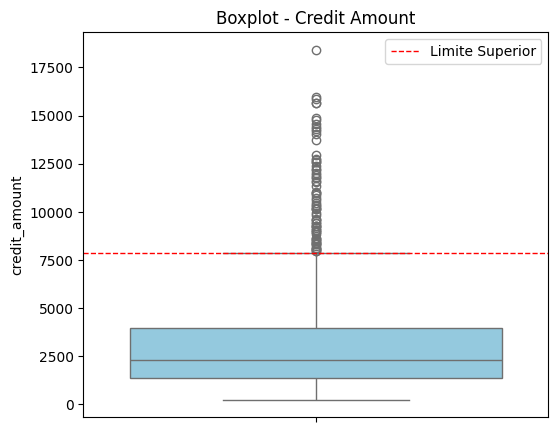

In [14]:
plt.figure(figsize=(6, 5))
sns.boxplot(df['credit_amount'], color='skyblue')
plt.axhline(ls_credit, color='red', linestyle='--', linewidth=1, label='Limite Superior')
plt.title("Boxplot - Credit Amount")
plt.legend()
plt.show()

In [15]:
outliers_credit['credit_amount'].min()

7966

In [16]:
outliers_credit

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
5,0,36,2,education,9055,0,2,2,male : single,none,...,unknown / no property,35,none,for free,1,unskilled - resident,2,"yes, registered under the customers name",yes,1
17,1,30,4,business,8072,0,1,2,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",25,bank,own,3,skilled employee / official,1,none,yes,1
18,2,24,2,car (used),12579,1,4,4,female : divorced/separated/married,none,...,unknown / no property,44,none,for free,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2
57,0,36,0,radio/television,9566,1,2,2,female : divorced/separated/married,none,...,"if not A121/A122 : car or other, not in attrib...",31,stores,own,2,skilled employee / official,1,none,yes,1
63,2,48,4,business,14421,1,2,2,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",25,none,own,1,skilled employee / official,1,"yes, registered under the customers name",yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,1,48,2,car (used),10297,1,3,4,male : single,none,...,unknown / no property,39,stores,for free,3,skilled employee / official,2,"yes, registered under the customers name",yes,2
945,2,48,4,car (new),8358,3,1,1,female : divorced/separated/married,none,...,"if not A121/A122 : car or other, not in attrib...",30,none,own,2,skilled employee / official,1,none,yes,1
953,0,36,2,furniture/equipment,10974,1,0,4,female : divorced/separated/married,none,...,"if not A121/A122 : car or other, not in attrib...",26,none,own,2,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2
980,2,30,0,furniture/equipment,8386,1,3,2,male : single,none,...,if not A121 : building society savings agreeme...,49,none,own,1,skilled employee / official,1,none,yes,2


In [17]:
outliers_credit.groupby('purpose')['credit_amount'].count()

,credit_amount
purpose,
business,11
car (new),17
car (used),21
education,5
furniture/equipment,5
others,5
radio/television,7
repairs,1


In [18]:
outliers_credit[['credit_amount', 'purpose']]

,credit_amount,purpose
5,9055,education
17,8072,business
18,12579,car (used)
57,9566,radio/television
63,14421,business
...,...,...
927,10297,car (used)
945,8358,car (new)
953,10974,furniture/equipment
980,8386,furniture/equipment


In [19]:
outliers_credit.groupby('purpose')['credit_amount'].agg(['count', 'mean', 'max']).sort_values('max', ascending=False)

,count,mean,max
purpose,,,
others,5,14465.800000,18424
business,11,11136.818182,15945
radio/television,7,11207.428571,15653
car (new),17,11415.294118,14896
furniture/equipment,5,10506.600000,14179
car (used),21,9802.285714,12976
education,5,9992.600000,12612
repairs,1,11998.000000,11998


In [20]:
outliers_credit[outliers_credit['purpose']== 'others'].sort_values('credit_amount', ascending=False)

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
915,2,48,4,others,18424,1,2,1,female : divorced/separated/married,none,...,if not A121 : building society savings agreeme...,32,bank,own,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",no,2
818,1,36,2,others,15857,1,0,2,male : divorced/separated,co-applicant,...,"if not A121/A122 : car or other, not in attrib...",43,none,own,1,management/ self-employed/ highly qualified em...,1,none,yes,1
374,2,60,3,others,14782,2,4,3,female : divorced/separated/married,none,...,unknown / no property,60,bank,for free,2,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2
105,2,24,0,others,11938,1,2,2,male : single,co-applicant,...,"if not A121/A122 : car or other, not in attrib...",39,none,own,2,management/ self-employed/ highly qualified em...,2,"yes, registered under the customers name",yes,2
431,2,24,2,others,11328,1,2,2,male : single,co-applicant,...,"if not A121/A122 : car or other, not in attrib...",29,bank,own,2,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2


In [21]:
outliers_credit[outliers_credit['purpose']== 'others'][['credit_amount']].sort_values('credit_amount', ascending=False)

,credit_amount
915,18424
818,15857
374,14782
105,11938
431,11328


In [22]:
outliers_credit.groupby('class')['credit_amount'].count()

,credit_amount
class,
1,33
2,39


In [23]:
outliers_credit.groupby(['purpose', 'class'])['credit_amount'].count().unstack()

class,1,2
purpose,,
business,3.0,8.0
car (new),7.0,10.0
car (used),12.0,9.0
education,3.0,2.0
furniture/equipment,1.0,4.0
others,1.0,4.0
radio/television,6.0,1.0
repairs,NaN,1.0


### 3.2 Outliers — duration

In [25]:
# Montante de crédito
q1_duration = df['duration'].quantile(0.25)
q3_duration = df['duration'].quantile(0.75)
iqr_duration = q3_duration - q1_duration
ls_duration = q3_duration + 1.5 * iqr_duration
li_duration = q1_duration - 1.5 * iqr_duration

outliers_duration = df[~df['duration'].between(li_duration, ls_duration)]
outliers_duration

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
1,2,48,2,radio/television,5951,1,2,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
11,1,48,2,business,4308,1,1,3,female : divorced/separated/married,none,...,if not A121 : building society savings agreeme...,24,none,rent,1,skilled employee / official,1,none,yes,2
29,1,60,1,business,6836,1,4,3,male : single,none,...,unknown / no property,63,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,2
35,2,45,0,radio/television,4746,1,1,4,male : single,none,...,if not A121 : building society savings agreeme...,25,none,own,2,unskilled - resident,1,none,yes,2
36,0,48,0,education,6110,1,2,1,male : single,none,...,unknown / no property,31,bank,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,2,48,4,car (new),8358,3,1,1,female : divorced/separated/married,none,...,"if not A121/A122 : car or other, not in attrib...",30,none,own,2,skilled employee / official,1,none,yes,1
973,1,60,2,business,7297,1,4,4,male : single,co-applicant,...,unknown / no property,36,none,rent,1,skilled employee / official,1,none,yes,2
981,0,48,2,business,4844,1,0,3,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",33,bank,rent,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2
998,1,45,2,radio/television,1845,1,2,4,male : single,none,...,unknown / no property,23,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2


In [26]:
print(f'Total de outliers: {len(outliers_duration)}')
print(outliers_duration['class'].value_counts())
print(outliers_duration['class'].value_counts(normalize=True) * 100)

Total de outliers: 70
class
2    40
1    30
Name: count, dtype: int64
class
2    57.142857
1    42.857143
Name: proportion, dtype: float64


In [27]:
ambos = outliers_duration[outliers_duration['credit_amount'] > ls_credit]
print(len(ambos))

26


### 3.3 Outliers — age

In [24]:
# Montante de crédito
q1_age = df['age'].quantile(0.25)
q3_age = df['age'].quantile(0.75)
iqr_age = q3_age - q1_age
ls_age = q3_age + 1.5 * iqr_age
li_age = q1_age - 1.5 * iqr_age

outliers_age = df[~df['age'].between(li_age, ls_age)]
outliers_age

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,class
0,1,6,0,radio/television,1169,0,4,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
75,1,12,0,car (used),1526,1,4,4,male : single,none,...,unknown / no property,66,none,for free,2,management/ self-employed/ highly qualified em...,1,none,yes,1
137,2,12,2,radio/television,766,3,2,4,male : single,none,...,real estate,66,none,own,1,unskilled - resident,1,none,yes,2
163,2,10,2,car (new),7308,1,0,2,male : single,none,...,unknown / no property,70,bank,for free,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,1
179,1,21,0,car (new),571,1,4,4,male : single,none,...,real estate,65,none,own,2,skilled employee / official,1,none,yes,1
186,2,9,3,car (used),5129,1,4,2,female : divorced/separated/married,none,...,unknown / no property,74,bank,for free,1,management/ self-employed/ highly qualified em...,2,"yes, registered under the customers name",yes,2
187,2,16,0,car (new),1175,1,0,2,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",68,none,for free,3,unemployed/ unskilled - non-resident,1,"yes, registered under the customers name",yes,1
213,3,30,1,business,1908,1,4,4,male : single,none,...,real estate,66,none,own,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,2
330,1,24,0,car (used),6615,1,0,2,male : single,none,...,unknown / no property,75,none,for free,2,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes,1
430,0,5,2,business,3448,1,3,1,male : single,none,...,real estate,74,none,own,1,unskilled - resident,1,none,yes,1


## 4. Correlação — Variáveis Numéricas (Pearson)
Correlação linear entre as variáveis numéricas/ordinais e o target `class`, além da verificação de multicolinearidade entre features.

In [28]:
colunas_numericas = [
    'duration', 'credit_amount', 'installment_rate',
    'residence_since', 'age', 'existing_credits', 'dependents'
]

corr = df[colunas_numericas + ['class']].corr()
corr

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,dependents,class
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_rate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
class,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


## 5. Correlação — Variáveis Categóricas (Cramér's V)
Associação entre variáveis categóricas nominais e o target, via teste qui-quadrado — métrica equivalente ao Pearson, mas adequada para categorias sem ordem.

In [29]:
from scipy.stats import chi2_contingency

# Função que calcula o Cramér's V entre duas colunas categóricas
def cramers_v(col1, col2):
    tabela = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    return np.sqrt(chi2 / (n * (min(tabela.shape) - 1)))

# Lista das colunas categóricas (nominais), sem personal_status_sex
colunas_categoricas = [
    'checking_account', 'credit_history', 'purpose', 'savings', 'employment',
    'other_debtors', 'property', 'other_installment_plans', 'housing',
    'job', 'telephone', 'foreign_worker'
]

# Calcula o Cramér's V de cada coluna categórica em relação a 'class'
resultados = {}
for col in colunas_categoricas:
    resultados[col] = cramers_v(df[col], df['class'])

# Transforma em tabela e ordena da maior associação pra menor
tabela_final = pd.Series(resultados).sort_values(ascending=False)

print(tabela_final)

checking_account           0.351740
credit_history             0.248378
savings                    0.189997
purpose                    0.182637
property                   0.154012
employment                 0.135530
housing                    0.134907
other_installment_plans    0.113310
other_debtors              0.081519
foreign_worker             0.076299
job                        0.043418
telephone                  0.034243
dtype: float64


In [30]:
# vendo multicorrelacionalidade

colunas_categoricas = [
    'checking_account', 'credit_history', 'purpose', 'savings', 'employment',
    'other_debtors', 'property', 'other_installment_plans', 'housing'
]

matriz_cramers = pd.DataFrame(index=colunas_categoricas, columns=colunas_categoricas, dtype=float)

for col1 in colunas_categoricas:
    for col2 in colunas_categoricas:
        matriz_cramers.loc[col1, col2] = cramers_v(df[col1], df[col2])

matriz_cramers

,checking_account,credit_history,purpose,savings,employment,other_debtors,property,other_installment_plans,housing
checking_account,1.000000,0.141812,0.149219,0.175569,0.095318,0.108532,0.075764,0.046248,0.098666
credit_history,0.141812,1.000000,0.167108,0.071509,0.100715,0.087507,0.079820,0.215368,0.097269
purpose,0.149219,0.167108,1.000000,0.113819,0.121738,0.165262,0.205818,0.143012,0.210169
savings,0.175569,0.071509,0.113819,1.000000,0.084650,0.096510,0.079109,0.021508,0.045151
employment,0.095318,0.100715,0.121738,0.084650,1.000000,0.083182,0.147126,0.070238,0.172929
other_debtors,0.108532,0.087507,0.165262,0.096510,0.083182,1.000000,0.142079,0.058402,0.059135
property,0.075764,0.079820,0.205818,0.079109,0.147126,0.142079,1.000000,0.081705,0.553181
other_installment_plans,0.046248,0.215368,0.143012,0.021508,0.070238,0.058402,0.081705,1.000000,0.089646
housing,0.098666,0.097269,0.210169,0.045151,0.172929,0.059135,0.553181,0.089646,1.000000


## 6. Seleção de Variáveis (Feature Selection)
Remoção de colunas por baixa correlação, viés ético (`personal_status_sex`, `foreign_worker`) ou multicolinearidade (`credit_amount`).

In [31]:
colunas_remover = [
    'personal_status_sex',   # viés estrutural
    'telephone',             # associação quase nula
    'job',                   # associação quase nula
    'foreign_worker',        # fraca + sensível eticamente
    'residence_since',       # correlação nula
    'dependents',            # correlação nula
    'credit_amount',         # multicolinearidade com duration
    'housing'             # multicolinearidade com property (opcional, seria mais conservador manter)
]

X= df.drop(columns=colunas_remover + ['class'])
y = df['class']

## 7. One-Hot Encoding (OHE)
Transformação das variáveis nominais em colunas binárias (`drop_first=True` para evitar a armadilha da variável dummy).

In [32]:
# fazendo one hot encoder
from sklearn.preprocessing import OneHotEncoder
colunas_nominais = ['purpose', 'property', 'other_debtors', 'other_installment_plans']
OHE = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

transform = OHE.fit_transform(X[colunas_nominais])

transform_df = pd.DataFrame(transform, columns=OHE.get_feature_names_out(colunas_nominais),
    index=X.index)

transform_df

,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,"property_if not A121/A122 : car or other, not in attribute 6",property_real estate,property_unknown / no property,other_debtors_guarantor,other_debtors_none,other_installment_plans_none,other_installment_plans_stores
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
998,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [33]:
X = transform_df

colunas_num = ['duration', 'age', 'installment_rate', 'existing_credits',
    'checking_account', 'credit_history', 'savings', 'employment']
X_final = pd.concat([df[colunas_num], X], axis=1)
X_final

,duration,age,installment_rate,existing_credits,checking_account,credit_history,savings,employment,purpose_car (new),purpose_car (used),...,purpose_radio/television,purpose_repairs,purpose_retraining,"property_if not A121/A122 : car or other, not in attribute 6",property_real estate,property_unknown / no property,other_debtors_guarantor,other_debtors_none,other_installment_plans_none,other_installment_plans_stores
0,6,67,4,2,1,0,0,4,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,48,22,2,1,2,2,1,2,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,12,49,2,1,0,0,1,3,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,42,45,2,1,1,2,1,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,24,53,3,2,1,1,1,2,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,31,3,1,0,2,1,3,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
996,30,40,4,1,1,2,1,2,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
997,12,38,4,1,0,2,1,4,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
998,45,23,4,1,1,2,1,2,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


## 8. Split Treino/Teste
Separação estratificada (`stratify=y`) para preservar a proporção 70/30 (Good/Bad) em treino e teste.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=0, stratify=y)

In [35]:
print(X_train.columns.tolist())

['duration', 'age', 'installment_rate', 'existing_credits', 'checking_account', 'credit_history', 'savings', 'employment', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture/equipment', 'purpose_others', 'purpose_radio/television', 'purpose_repairs', 'purpose_retraining', 'property_if not A121/A122 : car or other, not in attribute 6', 'property_real estate', 'property_unknown / no property', 'other_debtors_guarantor', 'other_debtors_none', 'other_installment_plans_none', 'other_installment_plans_stores']


## 9. Padronização (StandardScaler)
Escalonamento das variáveis numéricas — `fit` somente no treino, `transform` no treino e teste, evitando vazamento de dados (*data leakage*).

In [36]:
from sklearn.preprocessing import StandardScaler
colunas_para_escalar = [
    'duration', 'age', 'installment_rate', 'existing_credits',
    'checking_account', 'credit_history', 'savings', 'employment'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_para_escalar] = scaler.fit_transform(X_train[colunas_para_escalar])


## 10. Modelo — Regressão Logística
Treinamento do modelo base, sem ajustes de threshold ou peso de classe.

In [38]:
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(max_iter=1000, random_state=0)
modelo.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [40]:
y_pred = modelo.predict(X_test_scaled)

print(modelo.classes_)

[1 2]


## 11. Avaliação do Modelo Base
Matriz de confusão, classification report e cálculo do custo total, considerando a matriz de custo assimétrica do problema (erro Bad→Good custa 5x mais).

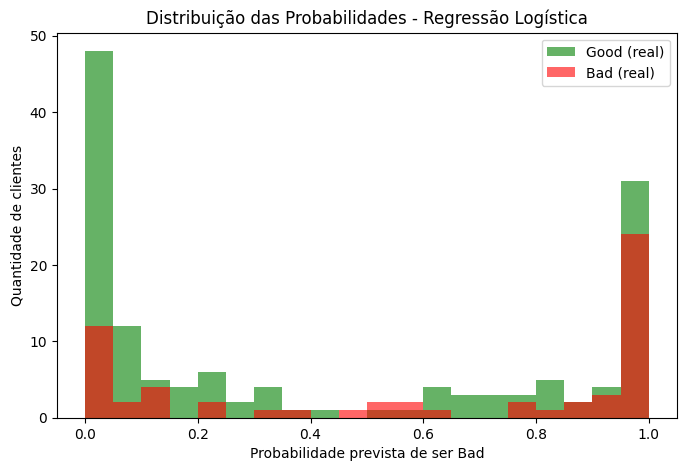

In [41]:
y_proba = modelo.predict_proba(X_test_scaled)[:,1]

plt.figure(figsize=(8, 5))
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.6, label='Good (real)', color='green')
plt.hist(y_proba[y_test == 2], bins=20, alpha=0.6, label='Bad (real)', color='red')
plt.xlabel('Probabilidade prevista de ser Bad')
plt.ylabel('Quantidade de clientes')
plt.title('Distribuição das Probabilidades - Regressão Logística')
plt.legend()
plt.show()

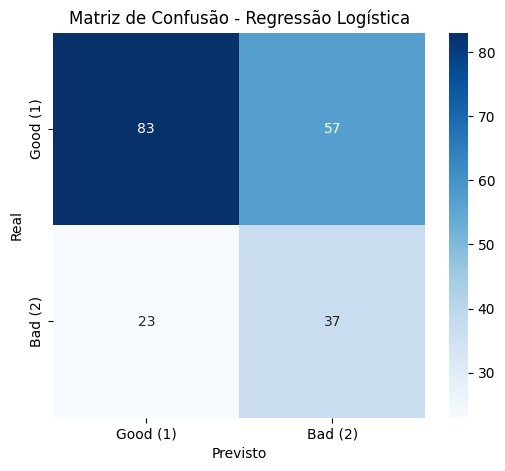

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = modelo.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good (1)', 'Bad (2)'],
            yticklabels=['Good (1)', 'Bad (2)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()



In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.78      0.59      0.67       140
           2       0.39      0.62      0.48        60

    accuracy                           0.60       200
   macro avg       0.59      0.60      0.58       200
weighted avg       0.67      0.60      0.62       200



## 12. Otimização — Ajuste de Threshold
Teste de diferentes pontos de corte de probabilidade, buscando o menor custo total.

In [45]:
def avaliar_threshold(threshold):
    y_pred_ajustado = np.where(y_proba >= threshold, 2, 1)
    cm = confusion_matrix(y_test, y_pred_ajustado)

    custo_matriz = np.array([[0, 1], [5, 0]])
    custo_total = (cm * custo_matriz).sum()

    print(f'--- Threshold = {threshold} ---')
    print(cm)
    print(classification_report(y_test, y_pred_ajustado))
    print(f'Custo total: {custo_total}\n')

for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    avaliar_threshold(t)

--- Threshold = 0.5 ---
[[83 57]
 [23 37]]
              precision    recall  f1-score   support

           1       0.78      0.59      0.67       140
           2       0.39      0.62      0.48        60

    accuracy                           0.60       200
   macro avg       0.59      0.60      0.58       200
weighted avg       0.67      0.60      0.62       200

Custo total: 172

--- Threshold = 0.4 ---
[[82 58]
 [22 38]]
              precision    recall  f1-score   support

           1       0.79      0.59      0.67       140
           2       0.40      0.63      0.49        60

    accuracy                           0.60       200
   macro avg       0.59      0.61      0.58       200
weighted avg       0.67      0.60      0.62       200

Custo total: 168

--- Threshold = 0.35 ---
[[81 59]
 [21 39]]
              precision    recall  f1-score   support

           1       0.79      0.58      0.67       140
           2       0.40      0.65      0.49        60

    accuracy    

In [46]:
for t in [0.15, 0.1, 0.05]:
    avaliar_threshold(t)

--- Threshold = 0.15 ---
[[65 75]
 [18 42]]
              precision    recall  f1-score   support

           1       0.78      0.46      0.58       140
           2       0.36      0.70      0.47        60

    accuracy                           0.54       200
   macro avg       0.57      0.58      0.53       200
weighted avg       0.66      0.54      0.55       200

Custo total: 165

--- Threshold = 0.1 ---
[[60 80]
 [14 46]]
              precision    recall  f1-score   support

           1       0.81      0.43      0.56       140
           2       0.37      0.77      0.49        60

    accuracy                           0.53       200
   macro avg       0.59      0.60      0.53       200
weighted avg       0.68      0.53      0.54       200

Custo total: 150

--- Threshold = 0.05 ---
[[48 92]
 [12 48]]
              precision    recall  f1-score   support

           1       0.80      0.34      0.48       140
           2       0.34      0.80      0.48        60

    accuracy   

In [47]:
for t in [0.12, 0.11, 0.1, 0.09, 0.08]:
    avaliar_threshold(t)

--- Threshold = 0.12 ---
[[60 80]
 [15 45]]
              precision    recall  f1-score   support

           1       0.80      0.43      0.56       140
           2       0.36      0.75      0.49        60

    accuracy                           0.53       200
   macro avg       0.58      0.59      0.52       200
weighted avg       0.67      0.53      0.54       200

Custo total: 155

--- Threshold = 0.11 ---
[[60 80]
 [14 46]]
              precision    recall  f1-score   support

           1       0.81      0.43      0.56       140
           2       0.37      0.77      0.49        60

    accuracy                           0.53       200
   macro avg       0.59      0.60      0.53       200
weighted avg       0.68      0.53      0.54       200

Custo total: 150

--- Threshold = 0.1 ---
[[60 80]
 [14 46]]
              precision    recall  f1-score   support

           1       0.81      0.43      0.56       140
           2       0.37      0.77      0.49        60

    accuracy   

## 13. Otimização — Peso de Classe (`class_weight`)
Comparação entre `class_weight='balanced'` (automático) e `class_weight={1:1, 2:5}` (manual, baseado na matriz de custo real).

In [49]:
modelo_balanceado = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
modelo_balanceado.fit(X_train_scaled, y_train)

y_pred_balanceado = modelo_balanceado.predict(X_test_scaled)

cm_bal = confusion_matrix(y_test, y_pred_balanceado)
custo_total_bal = (cm_bal * custo_matriz).sum()

print(cm_bal)
print(classification_report(y_test, y_pred_balanceado))
print(f'Custo total: {custo_total_bal}')

[[65 75]
 [18 42]]
              precision    recall  f1-score   support

           1       0.78      0.46      0.58       140
           2       0.36      0.70      0.47        60

    accuracy                           0.54       200
   macro avg       0.57      0.58      0.53       200
weighted avg       0.66      0.54      0.55       200

Custo total: 165


In [48]:
modelo_custo = LogisticRegression(max_iter=1000, random_state=0, class_weight={1: 1, 2: 5})
modelo_custo.fit(X_train_scaled, y_train)

y_pred_custo = modelo_custo.predict(X_test_scaled)

cm_custo = confusion_matrix(y_test, y_pred_custo)
custo_matriz = np.array([[0, 1], [5, 0]])
custo_total_custo = (cm_custo * custo_matriz).sum()

print(cm_custo)
print(classification_report(y_test, y_pred_custo))
print(f'Custo total: {custo_total_custo}')

[[48 92]
 [10 50]]
              precision    recall  f1-score   support

           1       0.83      0.34      0.48       140
           2       0.35      0.83      0.50        60

    accuracy                           0.49       200
   macro avg       0.59      0.59      0.49       200
weighted avg       0.68      0.49      0.49       200

Custo total: 142
